In [1]:
import numpy as np
from scipy.signal import convolve2d
from IDF import *
from SOMF_slope import *
from SOMF_flatten import *
import pytest

In [ ]:
# --- Test setup ---
def test_pwd_apply():
    n_samples = 100
    order = 3
    na = 2 * order + 1   # filter length

    # Synthetic input signal: simple sine wave + noise
    x = np.sin(np.linspace(0, 4*np.pi, n_samples)) + \
        0.05*np.random.randn(n_samples)

    # Generate position-dependent filters (n x na)
    # Here: small Gaussian-like kernels centered at each sample
    filts = np.zeros((n_samples, na))
    for i in range(n_samples):
        center_idx = order
        sigma2 = (order/2)**2
        weights = np.exp(-((np.arange(na)-center_idx)**2)/(2*sigma2))
        weights /= weights.sum()
        filts[i, :] = weights

    # Run forward operation
    y_forward = pwd_apply(x.copy(), filts.copy(), adj=False)

    # Run adjoint operation
    y_adjoint = pwd_apply(x.copy(), filts.copy(), adj=True)

    print("Input shape:", x.shape)
    print("Filter matrix shape:", filts.shape)
    print("Forward output shape:", y_forward.shape)
    print("Adjoint output shape:", y_adjoint.shape)

    assert y_forward.ndim == 1 and y_adjoint.ndim == 1, "Output must be vector"

    assert np.all(np.isfinite(y_forward)), "Forward output contains NaN or Inf"

    # Optional symmetry check (approximate energy equality)
    e_fwd = np.linalg.norm(y_forward)
    e_adj = np.linalg.norm(y_adjoint)
    print(f"Energy forward={e_fwd:.3f}, adjoint={e_adj:.3f}")
    assert abs(e_fwd-e_adj) / \
        max(e_fwd, e_adj) < 0.5, "Energy mismatch too large"


def test_pwd_op():
    n_samples = 50
    order = 3
    dips = np.linspace(-0.5, +0.5, n_samples)

    diag_base, off_base = simple_regularization(n_samples, order, eps=5e-3)

    print("Running pwd_op forward...")
    filt_forward, diag_fwd, off_fwd = pwd_op(
        dips.copy(), diag_base.copy(), off_base.copy(), order, f=True)

    print("Running pwd_op backward...")
    filt_backward, diag_bwd, off_bwd = pwd_op(
        dips.copy(), diag_base.copy(), off_base.copy(), order, f=False)

    # shape checks
    assert filt_forward.shape == (n_samples, (2*order+1))
    assert diag_fwd.shape == (n_samples,)
    # depending on implementation
    assert off_fwd.shape == (n_samples, (4)) or True

    # numeric sanity checks
    assert np.all(np.isfinite(filt_forward)), "NaN/Inf found"

    print("Filter coefficient ranges:")
    print(
        f"Forward min={filt_forward.min():.3e}, max={filt_forward.max():.3e}")
    print(
        f"Backward min={filt_backward.min():.3e}, max={filt_backward.max():.3e}")

    # Variation check — filters should vary with dip value.
    diff_norm = np.linalg.norm(
        filt_forward-filt_backward)/np.linalg.norm(filt_forward)
    print(f"Difference norm between forward/backward filters={diff_norm:.3f}")
    assert diff_norm > 0, "Filters identical? Check reversal logic."


def test_pwd_op_visual():
    n_samples = 60
    order = 3
    dips = np.linspace(-0.8, +0.8, n_samples)

    diag_base, off_base = simple_regularization(n_samples, order)

    filt_forward, diag_fwd, off_fwd = pwd_op(
        dips.copy(), diag_base.copy(), off_base.copy(), order, f=True)

    print("Filter matrix shape:", filt_forward.shape)
    print("Diag min/max:", diag_fwd.min(), diag_fwd.max())

    # Plot filter coefficients vs dip value
    plt.figure(figsize=(10, 5))
    for i_coeff in range(filt_forward.shape[1]):
        plt.plot(dips, filt_forward[:, i_coeff],
                 label=f"Coeff {i_coeff-order}" if i_coeff % 3 == 0 else None,
                 alpha=0.7)

    plt.title(f"PWD Filter Coefficients vs Dip (Order={order})")
    plt.xlabel("Dip value")
    plt.ylabel("Coefficient amplitude")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    # Show diagonal evolution too
    plt.figure(figsize=(6, 3))
    plt.plot(np.arange(n_samples), diag_fwd, 'r-', lw=2, label="Diagonal term")
    plt.title("Regularization diagonal after PWD operator assembly")
    plt.xlabel("Sample index")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()

    plt.show()


def test_pwd_op_visual_compare():
    n_samples = 60
    order = 3
    dips = np.linspace(-0.8, +0.8, n_samples)

    diag_base, off_base = simple_regularization(n_samples, order)

    filt_forward, diag_fwd, _ = pwd_op(
        dips.copy(), diag_base.copy(), off_base.copy(), order, f=True)
    filt_backward, diag_bwd, _ = pwd_op(
        dips.copy(), diag_base.copy(), off_base.copy(), order, f=False)

    print("Filter matrix shape:", filt_forward.shape)
    print("Diagonal ranges:", diag_fwd.min(), diag_fwd.max())

    # Plot forward vs backward filter coefficients side-by-side.
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for i_coeff in range(filt_forward.shape[1]):
        axes[0].plot(dips, filt_forward[:, i_coeff],
                     label=f"Coeff {i_coeff-order}" if i_coeff % 3 == 0 else None,
                     alpha=0.7)
        axes[1].plot(dips, filt_backward[:, i_coeff],
                     label=f"Coeff {i_coeff-order}" if i_coeff % 3 == 0 else None,
                     alpha=0.7)

    axes[0].set_title(f"Forward filters vs dip (Order={order})")
    axes[0].set_xlabel("Dip value")
    axes[0].set_ylabel("Coefficient amplitude")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].set_title("Backward filters vs dip")
    axes[1].set_xlabel("Dip value")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Compare difference energy between forward/backward filters.
    diff_norm = np.linalg.norm(
        filt_forward-filt_backward)/np.linalg.norm(filt_forward)
    print(
        f"Normalized difference between forward/backward filters={diff_norm:.3f}")


def test_allpass_filter_flat():
    orders = [2, 3, 4]
    dips = np.linspace(-1.0, 1.0, num=21)

    print("Testing numerical stability of allpass_filter_flat()...\n")

    # Check properties across dips and orders
    for order in orders:
        norms = []
        max_vals = []
        min_vals = []

        print(f"Order {order}:")
        for dip in dips:
            coeffs = allpass_filter_flat(dip, order)

            # Shape check
            assert coeffs.shape == (order*2+1,), f"Wrong shape: {coeffs.shape}"

            # Finite check
            assert np.all(np.isfinite(coeffs)), f"NaN or Inf at dip={dip}"

            # Norm check ~ should be ≈ 1 due to normalization
            norm_val = np.linalg.norm(coeffs)
            norms.append(norm_val)
            max_vals.append(coeffs.max())
            min_vals.append(coeffs.min())

        print(f"Norm range: [{min(norms):.3f}, {max(norms):.3f}]")
        print(
            f"Coeff amplitude range: [{min(min_vals):+.3e}, {max(max_vals):+.3e}]\n")

    # Visualization — coefficients vs dip for one order
    sel_order = 3
    coeff_matrix = np.array(
        [allpass_filter_flat(dip, sel_order) for dip in dips])

    plt.figure(figsize=(8, 5))
    for i_coeff in range(coeff_matrix.shape[1]):
        plt.plot(dips,
                 coeff_matrix[:, i_coeff],
                 label=f"Coeff {i_coeff-sel_order}" if i_coeff % 2 == 0 else None,
                 alpha=0.7)

    plt.title(f"All-pass Filter Coefficients vs Dip (Order={sel_order})")
    plt.xlabel("Dip value")
    plt.ylabel("Coefficient amplitude")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def test_solve_band_mat():
    print("Testing solve_band_mat()...\n")

    n = 10
    bandw = 4   # two sub/super diagonals → total bandwidth=4

    # Construct known symmetric positive definite banded system:
    diag_true = 4 * np.ones(n)

    # Two off-diagonals on each side with smaller values
    offd_true = np.zeros((n, bandw))
    offd_true[1:, bandw//2-1] = -1.0   # first lower diagonal
    offd_true[:-1, bandw//2] = -1.0   # first upper diagonal

    b = np.arange(1, n+1, dtype=float)

    # Solve using our wrapper
    x_custom = solve_band_mat(
        b.copy(), bandw, diag_true.copy(), offd_true.copy())

    # Build full dense matrix for comparison:
    A_dense = np.diag(diag_true)+np.diag(-np.ones(n-1),
                                         k=1)+np.diag(-np.ones(n-1), k=-1)

    x_ref = np.linalg.solve(A_dense, b)

    print("Custom solver result:", x_custom.round(6))
    print("Reference solver result:", x_ref.round(6))

    err_norm = np.linalg.norm(x_custom-x_ref)/np.linalg.norm(x_ref)
    print(f"Relative error norm: {err_norm:.3e}")

    assert err_norm < 1e-10, "Solver mismatch too large!"

    print("\n solve_band_mat passed numerical consistency check.")


def test_struct_flatten():
    print("Testing struct_flatten()...\n")

    # Synthetic parameters
    ns = 80   # spatial samples per trace
    nt = 20   # number of traces
    freq = 0.05
    slope = 0.4   # controls tilt / dip

    # Generate synthetic dipping sinusoidal data
    s = np.arange(ns)
    din = np.zeros((ns, nt))
    for i in range(nt):
        din[:, i] = np.sin(2 * np.pi * freq * (s + slope * i))

    # Dip field: constant value across space/time matching slope
    dips = np.ones_like(din) * slope

    # Run flattening with moderate radius/order for speed
    fl_din = struct_flatten(din, dips, radius=3)

    print("Input shape:", din.shape)
    print("Flattened cube shape:", fl_din.shape)

    # --- Visualization ---

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(din, aspect='auto', cmap='seismic')
    axes[0].set_title("Original dipping structure")
    axes[0].set_xlabel("Trace index")
    axes[0].set_ylabel("Sample index")

    axes[1].imshow(fl_din[:, :, fl_din.shape[2]//2],
                   aspect='auto', cmap='seismic')
    axes[1].set_title("Flattened middle slice")
    axes[1].set_xlabel("Trace index")
    axes[1].set_ylabel("Sample index")

    diff = np.abs(fl_din[:, :, fl_din.shape[2]//2]-din)
    im = axes[2].imshow(diff, aspect='auto', cmap='viridis')
    axes[2].set_title("|Flattened - Input| difference")
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    # --- Numerical sanity ---
    assert fl_din.ndim == 3, "Output must be 3D"
    assert np.all(np.isfinite(fl_din)), "NaN/Inf found in flattened cube"

    mean_diff = np.mean(diff)
    print(
        f"Mean absolute difference between input and middle flattened slice: {mean_diff:.3e}")

    print("\n struct_flatten executed successfully.")


def test_struct_flatten_varying_slopes():
    print("Testing struct_flatten() with varying slopes...\n")

    # Synthetic parameters
    ns = 80   # spatial samples per trace (vertical)
    nt = 20   # number of traces (horizontal)
    freq = 0.05

    # Create varying slopes from -0.5 to +0.5 across traces
    slopes = np.linspace(-0.5, +0.5, nt)

    # Generate synthetic dipping sinusoidal data
    s = np.arange(ns)
    din = np.zeros((ns, nt))
    for i in range(nt):
        din[:, i] = np.sin(2 * np.pi * freq * (s + slopes[i] * i))

    # Dip field: same slope pattern repeated along sample axis
    dips = np.tile(slopes, (ns, 1))

    # Run flattening with moderate parameters
    fl_din = struct_flatten(din, dips, radius=4)

    print("Input shape:", din.shape)
    print("Flattened cube shape:", fl_din.shape)

    # --- Visualization ---
    fig, axes = plt.subplots(1, 5, figsize=(15, 4))

    axes[0].imshow(din, aspect='auto', cmap='seismic')
    axes[0].set_title("Original structure with varying dips")
    axes[0].set_xlabel("Trace index")
    axes[0].set_ylabel("Sample index")

    first_slice = fl_din[:, :, 0]
    axes[1].imshow(first_slice, aspect='auto', cmap='seismic')
    axes[1].set_title("Flattened first slice")
    axes[1].set_xlabel("Trace index")
    axes[1].set_ylabel("Sample index")

    mid_slice = fl_din[:, :, fl_din.shape[2]//2]
    axes[2].imshow(mid_slice, aspect='auto', cmap='seismic')
    axes[2].set_title("Flattened middle slice")
    axes[2].set_xlabel("Trace index")
    axes[2].set_ylabel("Sample index")

    slopes = local_slope_estimation(
        din, n_iter=2, l_iter=10, order=3, eps_dv=1, eps_cg=1, tol_cg=1e-6, rect=np.array([1, 1]), gaussian_sigma=10)
    axes[3].imshow(slopes, aspect='auto', cmap='seismic')
    axes[3].set_title("Slopes")
    axes[3].set_xlabel("Trace index")
    axes[3].set_ylabel("Sample index")

    diff = np.abs(mid_slice-din)
    im = axes[4].imshow(diff, aspect='auto', cmap='viridis')
    axes[4].set_title("|Flattened - Input| difference")
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    # --- Numerical sanity checks ---
    assert fl_din.ndim == 3, "Output must be 3D"
    assert np.all(np.isfinite(fl_din)), "NaN/Inf found in flattened cube"

    mean_diff = np.mean(diff)
    print(
        f"Mean absolute difference between input and middle flattened slice: {mean_diff:.3e}")

    print("\n struct_flatten executed successfully on varying slope data.")

# --- Test setup ---


def test_SOMF():
    print("Testing SOMF pipeline...\n")

    ns = 80
    nt = 30
    freq = 0.05

    # Generate synthetic dipping sinusoidal dataset with noise
    s = np.arange(ns)
    slopes = np.linspace(-0.4, +0.4, nt)

    data = np.zeros((ns, nt))
    for i in range(nt):
        data[:, i] = np.sin(2*np.pi*freq*(s+slopes[i]*i)) + \
            0.15*np.random.randn(ns)

    input = data.copy()

    # result = SOMF(data, input, n_iter=2, l_iter=10, dip_order=3, rect=np.array(
    #    [1, 1]), eps_dv=1e-1, eps_cg=1e-2, tol_cg=1e-6, radius=8, flat_order=3, eps=1e-4, eps2=1e-4, slope_mask_coeff=0.05)

    result = SOMF(data, input, n_iter=5, l_iter=20, dip_order=3, eps_dv=1e-2, eps_cg=1,
                  tol_cg=1e-6, rect=np.array([1, 1]), gaussian_sigma=10, radius=4, slope_mask_coeff=0.05)

    print("Input shape:", input.shape, "Output shape:", result.shape)

    # Visualization comparison
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(input, aspect='auto', cmap='seismic')
    axes[0].set_title("Original noisy dipping structure")
    axes[0].set_xlabel("Trace index")
    axes[0].set_ylabel("Sample index")

    axes[1].imshow(result, aspect='auto', cmap='seismic')
    axes[1].set_title("After SOMF filtering")
    axes[1].set_xlabel("Trace index")
    axes[1].set_ylabel("Sample index")

    diff = np.abs(result - input)
    im = axes[2].imshow(diff, cmap='viridis', aspect='auto')
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    axes[2].set_title("|Filtered - Input| difference")
    axes[2].set_xlabel("Trace index")
    axes[2].set_ylabel("Sample index")

    plt.tight_layout()
    plt.show()

    mean_diff = np.mean(diff)
    print(
        f"Mean absolute difference between input and filtered result: {mean_diff:.3e}")

    assert np.all(np.isfinite(result)), "NaN/Inf found in output"

    print("\n SOMF executed successfully on synthetic varying-slope data.")

Testing struct_flatten() with varying slopes...

Input shape: (80, 20)
Flattened cube shape: (80, 20, 9)


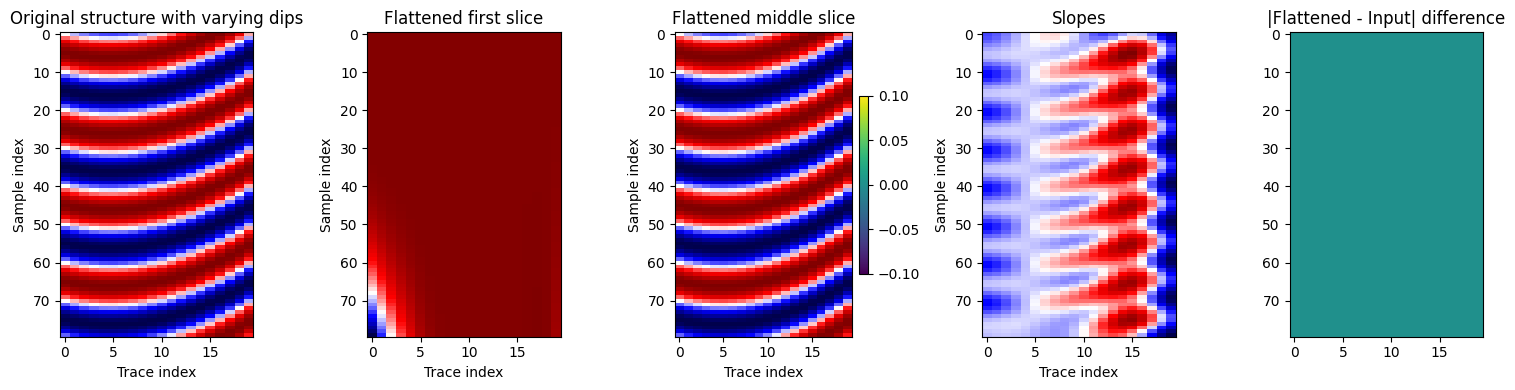

Mean absolute difference between input and middle flattened slice: 0.000e+00

 struct_flatten executed successfully on varying slope data.


In [3]:
test_struct_flatten_varying_slopes()

Testing SOMF pipeline...

output shape: (80, 30)
Input shape: (80, 30) Output shape: (80, 30)


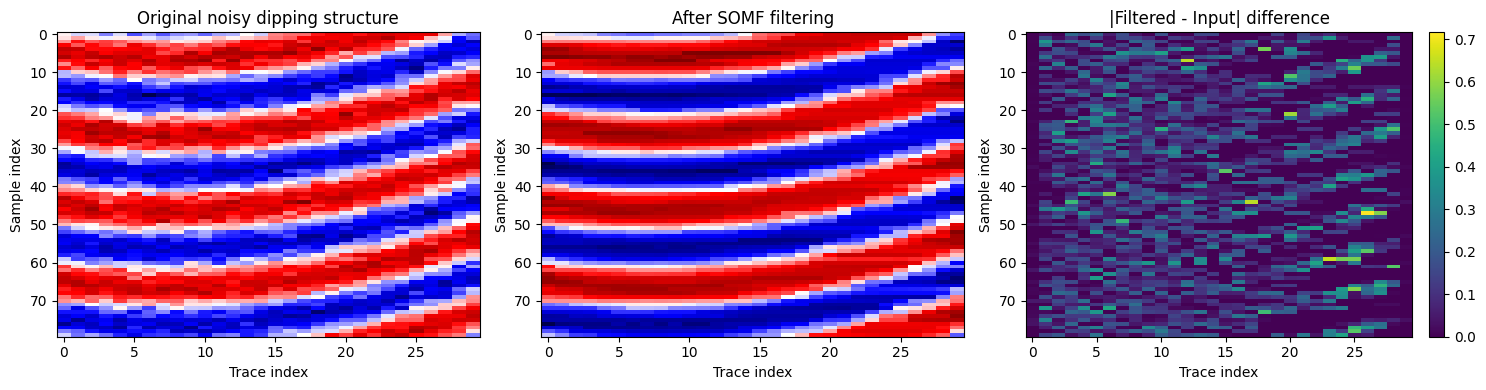

Mean absolute difference between input and filtered result: 9.235e-02

 SOMF executed successfully on synthetic varying-slope data.


In [8]:
test_SOMF()

True slope: 0.5
Mean estimated slope: -2.2276624989103765e-17


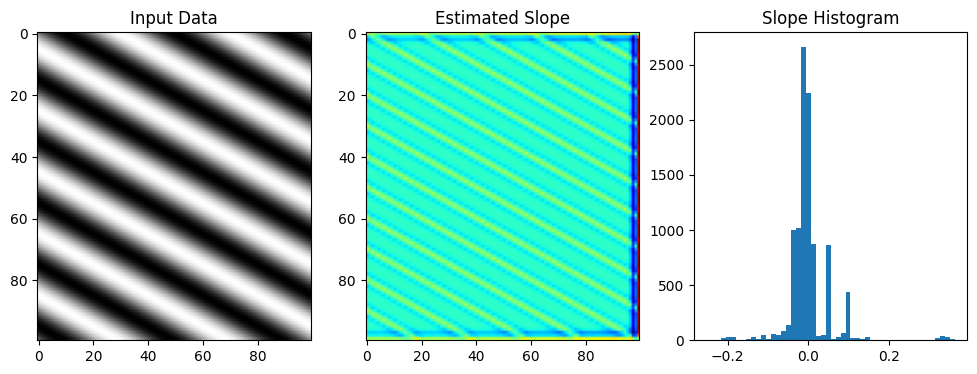

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Create synthetic plane wave with known slope
n1, n2 = 100, 100
true_slope = 0.5   # dt/dx or dz/dx depending on convention

x = np.arange(n2)
t = np.arange(n1)
T, X = np.meshgrid(t, x, indexing='ij')

# Generate a linear event: t - sigma*x
dn = np.sin(2*np.pi*(T - true_slope*X)/20)

# Estimate slopes
sigma_est = local_slope_estimation(dn,
                                   n_iter=1,
                                   l_iter=20,
                                   order=3,
                                   eps_dv=1e-2,
                                   eps_cg=1e-4,
                                   tol_cg=1e-6,
                                   rect=np.array([1,1]),
                                   )

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(dn, aspect='auto', cmap='gray')
plt.title("Input Data")
plt.subplot(132)
plt.imshow(sigma_est, aspect='auto', cmap='jet')
plt.title("Estimated Slope")
plt.subplot(133)
plt.hist(sigma_est.flatten(), bins=50)
plt.title("Slope Histogram")
plt.subplot(133)

print("True slope:", true_slope)
print("Mean estimated slope:", np.mean(sigma_est))

In [6]:
print(sigma_est)
np.savetxt('slopes_output.txt', sigma_est)

[[ 0.16771106  0.07926943  0.07145646 ...  0.08032904  0.02876526
   0.07548644]
 [-0.04623458 -0.00961797  0.05936772 ... -0.17488839 -0.09584475
   0.26005528]
 [-0.09136001 -0.06116252 -0.02526655 ... -0.25086127 -0.13639164
   0.35228009]
 ...
 [-0.04326686 -0.04327541 -0.04329577 ... -0.2527129  -0.15393528
   0.345619  ]
 [-0.02531312 -0.02531794 -0.0253276  ... -0.14176297 -0.11661328
   0.24993677]
 [ 0.08122071  0.08123624  0.08126721 ...  0.07137643  0.00888698
   0.06831403]]
